In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [27]:
df = pd.read_csv('enrollment_data_combined.csv', dtype=str)
df.head()

,Subject,#,Title,Comp Numb,Sec,Ptrm,Lec Lab,Attr,Camp Code,Coll Code,...,GP Ind,Instructor,NetId,Email,Fees,XListings,Year,Semester,Instructor Last,Instructor First
0,ABIO,6020,ABIO Graduate Seminar,13772,A,1,SEM,NaN,M,CALS,...,Y,"Machado de Sant'Anna, Felipe",fsantann,Felipe.Santanna@uvm.edu,NaN,,2025,Spring,Machado de Sant'Anna,Felipe
1,ABIO,6391,Master's Thesis Research,13766,A,1,TD,NaN,M,CALS,...,N,"Kraft, Jana",jkraft1,Jana.Kraft@uvm.edu,NaN,,2025,Spring,Kraft,Jana
2,ABIO,6391,Master's Thesis Research,13767,B,1,TD,NaN,M,CALS,...,N,"Barlow, John William",jbarlow,John.Barlow@uvm.edu,NaN,,2025,Spring,Barlow,John William
3,ABIO,6391,Master's Thesis Research,13768,C,1,TD,NaN,M,CALS,...,N,"Smith, Julie M",jmsmith,Julie.M.Smith@uvm.edu,NaN,,2025,Spring,Smith,Julie M
4,ABIO,6391,Master's Thesis Research,13769,D,1,TD,NaN,M,CALS,...,N,"Zhao, Feng-Qi",fzhao,fzhao@uvm.edu,NaN,,2025,Spring,Zhao,Feng-Qi


In [28]:
# Explore unique values in each column
for col in df.columns:
    n_unique = df[col].nunique()
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(f"Number of unique values: {n_unique}")

    if n_unique < 40:
        print(f"Unique values with counts:")
        value_counts = df[col].value_counts()
        for val, count in value_counts.items():
            print(f"  - {val}: {count}")
    print('='*60)


Column: Subject
Number of unique values: 217

Column: #
Number of unique values: 1444

Column: Title
Number of unique values: 26736

Column: Comp Numb
Number of unique values: 16233

Column: Sec
Number of unique values: 1528

Column: Ptrm
Number of unique values: 18
Unique values with counts:
  - 1: 68792
  - ZF: 492
  - ZC: 339
  - ZD: 328
  - ZG: 217
  - ZH: 175
  - ZI: 110
  - ZZ: 34
  - ZA: 33
  - A: 27
  - B: 25
  - ZB: 24
  - ZN: 11
  - ZJ: 9
  - ZK: 7
  - ZL: 6
  - ZM: 3
  - ZE: 2

Column: Lec Lab
Number of unique values: 34
Unique values with counts:
  - L: 56853
  - LEC: 51005
  - TD: 47817
  - LAB: 15954
  - B: 10207
  - SEM: 8632
  - ONL: 7682
  - T: 5650
  - PERF: 5245
  - HYBD: 4422
  - A: 4420
  - INTN: 4388
  - IS: 4076
  - ACT: 4069
  - RSCH: 3956
  - LCDS: 3309
  - H: 3101
  - I: 2702
  - LCLB: 2445
  - P: 2159
  - LSN: 1979
  - PRAC: 1931
  - O: 1817
  - STD: 1645
  - TA: 1481
  - CLN: 1453
  - D: 1210
  - DIS: 1112
  - FWRK: 438
  - REC: 276
  - R: 202
  - C: 200
  

In [29]:
print(len(df))  # Print the length of the DataFrame

261847


In [30]:
# Departments with the most courses
dept_counts = df.groupby('Subject').size().sort_values(ascending=False)

print("="*70)
print("DEPARTMENTS WITH THE MOST COURSES")
print("="*70)
print(f"\nTop 20 departments by total course offerings:\n")

for i, (dept, count) in enumerate(dept_counts.head(20).items(), 1):
    print(f"{i:2d}. {dept:8s}: {count:5d} courses")

print("\n" + "="*70)
print(f"Total departments: {len(dept_counts)}")
print(f"Total courses: {dept_counts.sum()}")
print(f"Average courses per department: {dept_counts.mean():.1f}")
print(f"Median courses per department: {dept_counts.median():.0f}")

DEPARTMENTS WITH THE MOST COURSES

Top 20 departments by total course offerings:

 1. GRAD    : 29214 courses
 2. CHEM    : 10034 courses
 3. PEAC    :  8400 courses
 4. NR      :  7178 courses
 5. MATH    :  7041 courses
 6. BSAD    :  5911 courses
 7. ENGS    :  5792 courses
 8. MU      :  5717 courses
 9. BIOL    :  5716 courses
10. CDAE    :  5347 courses
11. CS      :  4581 courses
12. ENVS    :  3965 courses
13. ME      :  3856 courses
14. HST     :  3768 courses
15. MUL     :  3506 courses
16. PRNU    :  3468 courses
17. PHYS    :  3420 courses
18. PSS     :  3394 courses
19. EE      :  3228 courses
20. SPAN    :  3136 courses

Total departments: 217
Total courses: 261847
Average courses per department: 1206.7
Median courses per department: 444


In [31]:
missing_first_names = (df['Instructor First'].isnull() & df["Instructor Last"].notnull())
df[missing_first_names]

,Subject,#,Title,Comp Numb,Sec,Ptrm,Lec Lab,Attr,Camp Code,Coll Code,...,GP Ind,Instructor,NetId,Email,Fees,XListings,Year,Semester,Instructor Last,Instructor First
172190,AIS,096,The Global Village,13248,A,NaN,L,NaN,M,NaN,...,NaN,Acquisto,NaN,NaN,NaN,NaN,2009,Spring,Acquisto,NaN
172191,AIS,096,Travel Study:DominicanRepublic,13266,TR1,NaN,L,NaN,C,NaN,...,NaN,Devitt,NaN,NaN,NaN,NaN,2009,Spring,Devitt,NaN
172192,AIS,096,Terrorism:An Asian Perspective,13250,WQ1,NaN,L,NaN,C,NaN,...,NaN,Ali,NaN,NaN,NaN,NaN,2009,Spring,Ali,NaN
172193,AIS,096,Terrorism:An Asian Perspective,13251,WQ2,NaN,L,NaN,C,NaN,...,NaN,Ali,NaN,NaN,NaN,NaN,2009,Spring,Ali,NaN
172194,AIS,096,Arch & Cult Hst Russ Capitals,13263,Z1,NaN,L,NaN,C,NaN,...,NaN,McKenna,NaN,NaN,NaN,NaN,2009,Spring,McKenna,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261842,WST,195,Psychology of Women,92397,E,NaN,L,NaN,C,NaN,...,NaN,Downey Sar,NaN,NaN,NaN,NaN,1995,Fall,Downey Sar,NaN
261843,WST,195,Women & Depression,92416,F,NaN,L,NaN,C,NaN,...,NaN,Gleeson,NaN,NaN,NaN,NaN,1995,Fall,Gleeson,NaN
261844,WST,195,Women's Spirituality,92417,G,NaN,L,NaN,C,NaN,...,NaN,Cleary,NaN,NaN,NaN,NaN,1995,Fall,Cleary,NaN
261845,WST,195,Gender & Law,92492,H,NaN,L,NaN,C,NaN,...,NaN,Taormina,NaN,NaN,NaN,NaN,1995,Fall,Taormina,NaN


In [32]:
# Drop 2025 data because it's incomplete
df = df[df['Year'] != '2025']

In [33]:
# create number of courses taught per department per year
courses_per_dept_year = df.groupby(['Year', 'Subject']).size().reset_index(name='Count')
courses_per_dept_year_pivot = courses_per_dept_year.pivot(index='Year', columns='Subject', values='Count').fillna(0)
courses_per_dept_year_pivot

Subject,ABIO,AGBI,AGRI,AH,AIS,ALAN,ALE,ANFS,ANNB,ANPS,...,TENU,THE,TRC,VS,WFB,WGST,WLIT,WR,WST,ZOOL
Year,,,,,,,,,,,,,,,,,,,,,
1995,0.0,37.0,34.0,28.0,0.0,0.0,0.0,0.0,22.0,17.0,...,10.0,41.0,0.0,0.0,25.0,0.0,0.0,3.0,22.0,27.0
1996,0.0,38.0,34.0,31.0,0.0,0.0,0.0,0.0,20.0,18.0,...,4.0,38.0,0.0,0.0,28.0,0.0,0.0,3.0,29.0,0.0
1997,0.0,36.0,32.0,34.0,0.0,7.0,0.0,0.0,21.0,19.0,...,0.0,40.0,0.0,0.0,28.0,0.0,0.0,3.0,33.0,0.0
1998,0.0,34.0,35.0,33.0,0.0,6.0,0.0,0.0,20.0,19.0,...,0.0,41.0,0.0,2.0,30.0,0.0,0.0,3.0,43.0,0.0
1999,0.0,31.0,33.0,40.0,0.0,9.0,0.0,0.0,22.0,18.0,...,0.0,43.0,0.0,1.0,33.0,0.0,0.0,3.0,36.0,0.0
2000,0.0,29.0,42.0,32.0,0.0,9.0,0.0,0.0,20.0,18.0,...,0.0,48.0,0.0,2.0,32.0,0.0,6.0,3.0,41.0,0.0
2001,0.0,18.0,54.0,26.0,0.0,10.0,0.0,0.0,20.0,19.0,...,0.0,56.0,0.0,12.0,40.0,0.0,20.0,2.0,31.0,0.0
2002,0.0,23.0,43.0,11.0,18.0,11.0,0.0,0.0,23.0,18.0,...,0.0,45.0,0.0,13.0,35.0,0.0,17.0,3.0,41.0,0.0
2003,0.0,23.0,39.0,0.0,22.0,9.0,0.0,0.0,22.0,18.0,...,0.0,50.0,0.0,11.0,45.0,0.0,17.0,0.0,33.0,0.0


/var/folders/yz/s7yhnqx575nf_63f35422l8m0000gn/T/ipykernel_55050/3416728729.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 640x480 with 0 Axes>

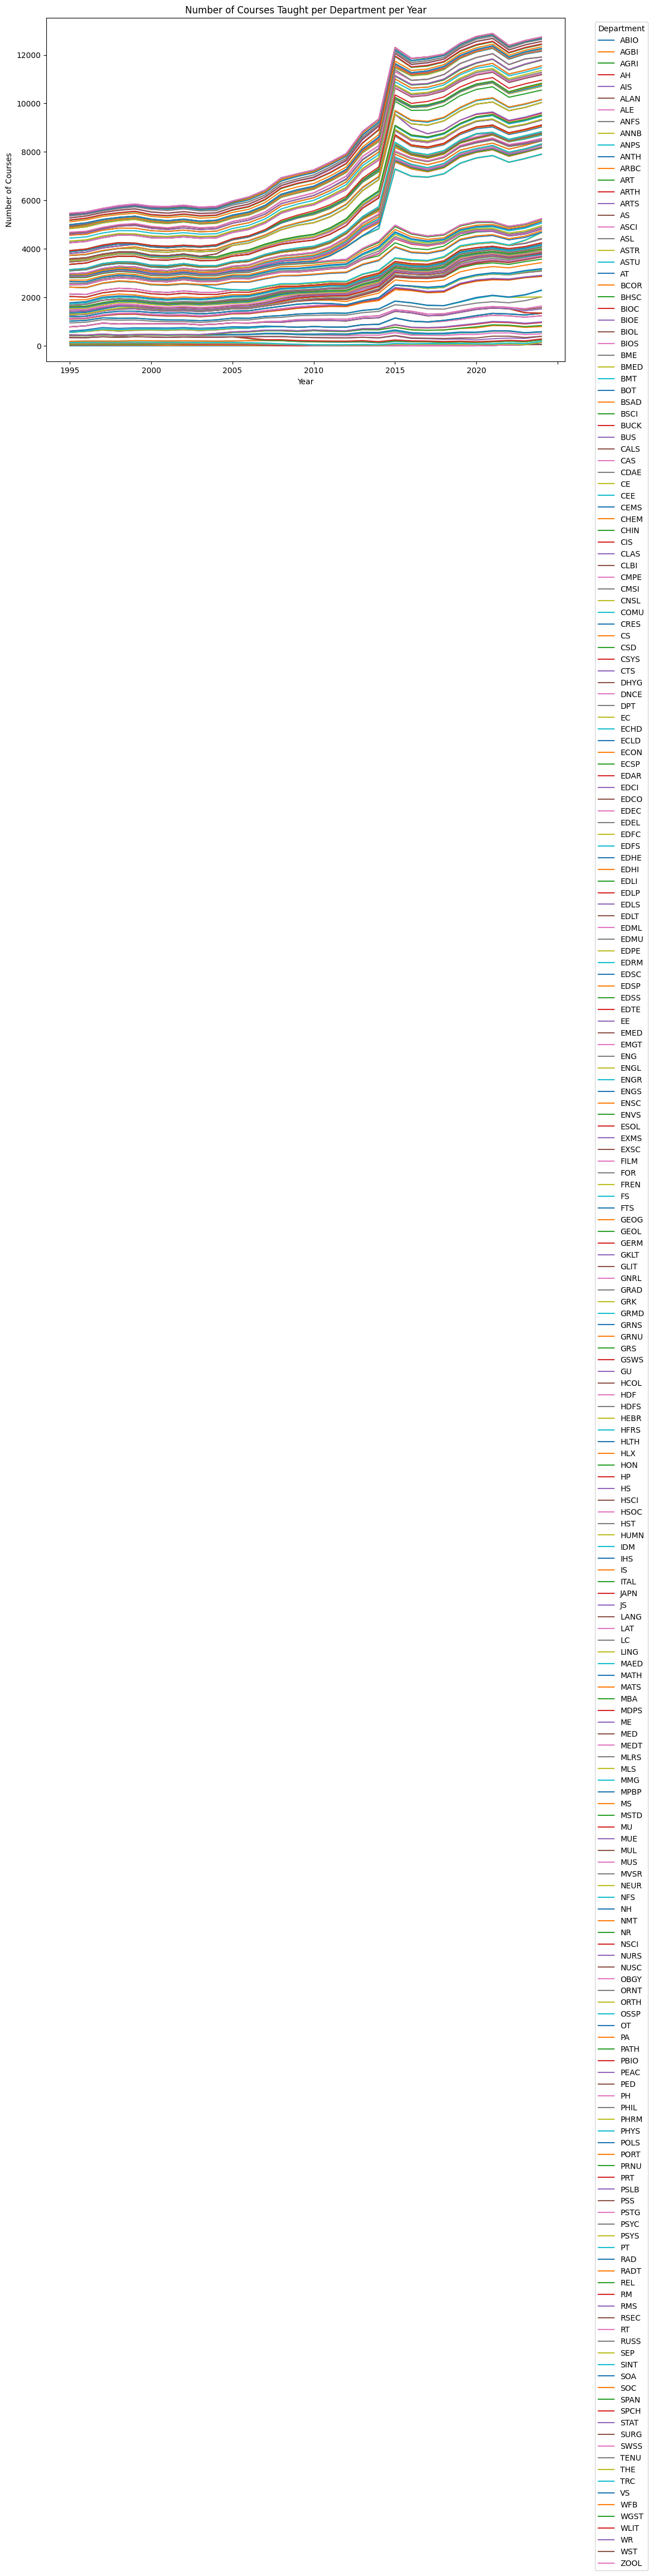

In [34]:
plt.figure()
courses_per_dept_year_pivot.plot(kind='line', stacked=True, figsize=(12, 8))
plt.title('Number of Courses Taught per Department per Year')
plt.xlabel('Year')
plt.ylabel('Number of Courses')
plt.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/yz/s7yhnqx575nf_63f35422l8m0000gn/T/ipykernel_55050/2965139047.py:33: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


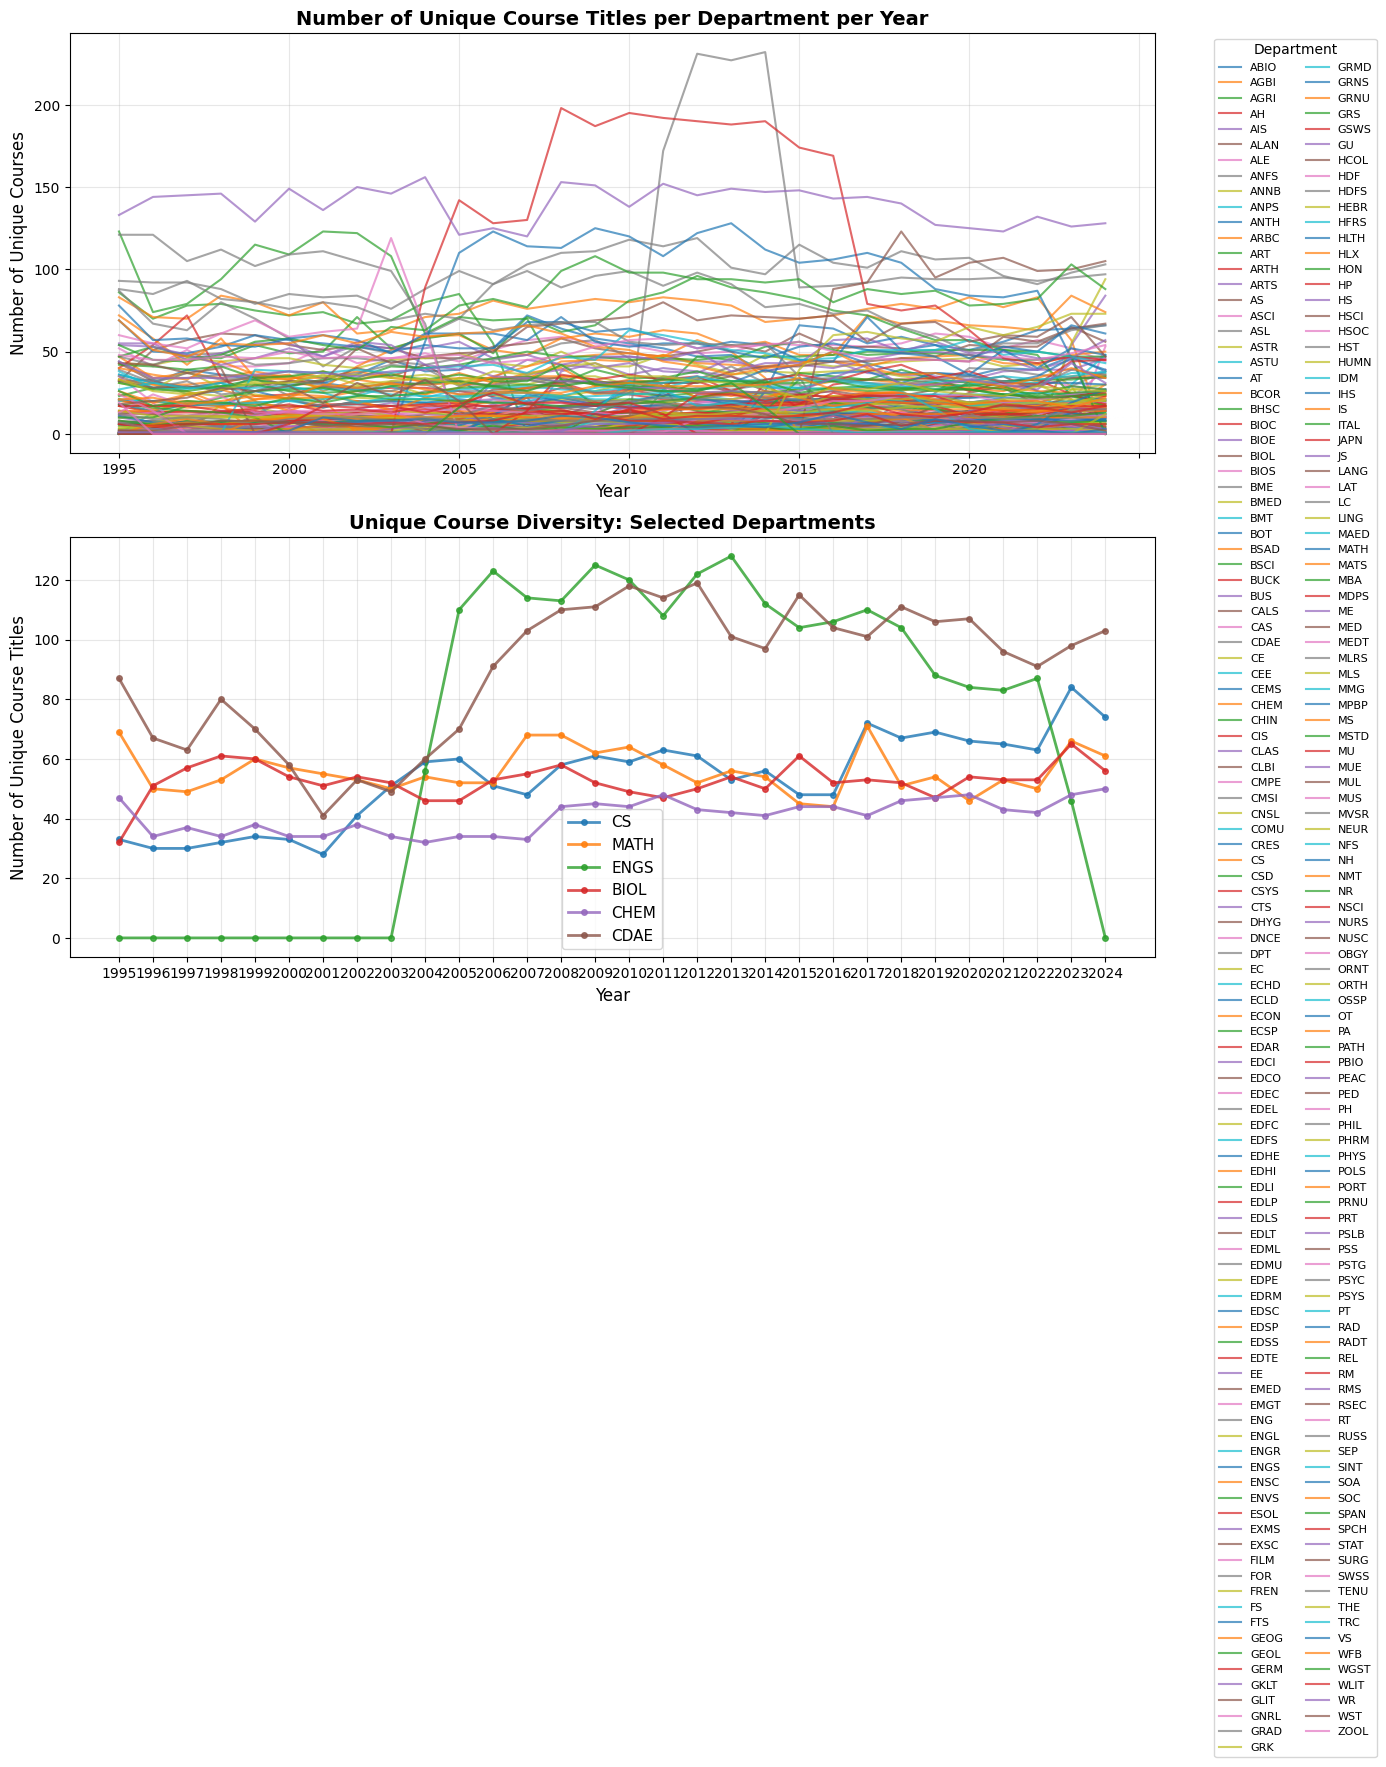


UNIQUE COURSE DIVERSITY STATISTICS

CS:
  Average unique courses per year: 53.2
  Max unique courses (year): 84 (2023)
  Min unique courses (year): 28 (2001)
  Change over period: +124.2%

MATH:
  Average unique courses per year: 55.9
  Max unique courses (year): 71 (2017)
  Min unique courses (year): 44 (2016)
  Change over period: -11.6%

ENGS:
  Average unique courses per year: 68.1
  Max unique courses (year): 128 (2013)
  Min unique courses (year): 0 (1995)

BIOL:
  Average unique courses per year: 52.6
  Max unique courses (year): 65 (2023)
  Min unique courses (year): 32 (1995)
  Change over period: +75.0%

CHEM:
  Average unique courses per year: 40.8
  Max unique courses (year): 50 (2024)
  Min unique courses (year): 32 (2004)
  Change over period: +6.4%

CDAE:
  Average unique courses per year: 89.8
  Max unique courses (year): 119 (2012)
  Min unique courses (year): 41 (2001)
  Change over period: +18.4%


In [35]:
# Number of Unique Courses per Department per Year
# Count unique course titles per department per year
unique_courses_per_dept_year = df.groupby(['Year', 'Subject'])['Title'].nunique().reset_index(name='Unique_Courses')
unique_courses_pivot = unique_courses_per_dept_year.pivot(index='Year', columns='Subject', values='Unique_Courses').fillna(0)

# Create figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: All departments line plot
ax1 = axes[0]
unique_courses_pivot.plot(kind='line', ax=ax1, alpha=0.7, linewidth=1.5)
ax1.set_title('Number of Unique Course Titles per Department per Year', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Unique Courses', fontsize=12)
ax1.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

# Plot 2: Selected departments line plot
selected_depts = ['CS', 'MATH', 'ENGS', 'BIOL', 'CHEM', 'CDAE']
ax2 = axes[1]

for dept in selected_depts:
    if dept in unique_courses_pivot.columns:
        ax2.plot(unique_courses_pivot.index, unique_courses_pivot[dept],
                marker='o', linewidth=2, markersize=4, label=dept, alpha=0.8)

ax2.set_title('Unique Course Diversity: Selected Departments', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Number of Unique Course Titles', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('unique_courses_per_department_year.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("UNIQUE COURSE DIVERSITY STATISTICS")
print("="*70)

for dept in selected_depts:
    if dept in unique_courses_pivot.columns:
        dept_data = unique_courses_pivot[dept]
        print(f"\n{dept}:")
        print(f"  Average unique courses per year: {dept_data.mean():.1f}")
        print(f"  Max unique courses (year): {dept_data.max():.0f} ({dept_data.idxmax()})")
        print(f"  Min unique courses (year): {dept_data.min():.0f} ({dept_data.idxmin()})")

        # Calculate growth
        if len(dept_data) > 1:
            first_year_val = dept_data.iloc[0]
            last_year_val = dept_data.iloc[-1]
            if first_year_val > 0:
                pct_change = ((last_year_val - first_year_val) / first_year_val) * 100
                print(f"  Change over period: {pct_change:+.1f}%")

In [36]:
# Lexical Novelty Analysis - Innovation Rate per Department
# Track when new course titles appear for the first time

# Prepare data
df_novelty = df.copy()
df_novelty['Year'] = df_novelty['Year'].astype(int)
df_novelty = df_novelty.sort_values(['Subject', 'Year'])
df_novelty['Title'] = df_novelty['Title'].str.strip().str.lower()


# Dictionary to store results
novelty_results = []

# For each department
for dept in df_novelty['Subject'].unique():
    dept_df = df_novelty[df_novelty['Subject'] == dept].copy()

    # Track when each title first appears
    title_first_year = dept_df.groupby('Title')['Year'].min().to_dict()

    # For each year in this department
    for year in sorted(dept_df['Year'].unique()):
        year_df = dept_df[dept_df['Year'] == year]

        # Count total courses
        total_courses = len(year_df)

        # Count how many titles are appearing for the first time this year
        new_titles = [title for title in year_df['Title'].unique()
                     if title_first_year[title] == year]
        new_title_count = len(new_titles)

        # Calculate novelty rate
        novelty_rate = new_title_count / total_courses if total_courses > 0 else 0

        novelty_results.append({
            'Department': dept,
            'Year': year,
            'New_Title_Count': new_title_count,
            'Total_Courses': total_courses,
            'Novelty_Rate': novelty_rate
        })

# Create DataFrame
novelty_df = pd.DataFrame(novelty_results)

print("Lexical Novelty Analysis Complete")
print(f"Total departments analyzed: {novelty_df['Department'].nunique()}")
print(f"Year range: {novelty_df['Year'].min()} - {novelty_df['Year'].max()}")
print("\nSample of results:")
print(novelty_df.head(10))

# Save to CSV for further analysis
novelty_df.to_csv('department_novelty_timeseries.csv', index=False)
print("\nSaved to 'department_novelty_timeseries.csv'")

Lexical Novelty Analysis Complete
Total departments analyzed: 217
Year range: 1995 - 2024

Sample of results:
  Department  Year  New_Title_Count  Total_Courses  Novelty_Rate
0       ABIO  2021                1             17      0.058824
1       ABIO  2022                0             36      0.000000
2       ABIO  2023                3             46      0.065217
3       ABIO  2024                3             63      0.047619
4       AGBI  1995               20             37      0.540541
5       AGBI  1996                5             38      0.131579
6       AGBI  1997                1             36      0.027778
7       AGBI  1998                1             34      0.029412
8       AGBI  1999                0             31      0.000000
9       AGBI  2000                0             29      0.000000

Saved to 'department_novelty_timeseries.csv'


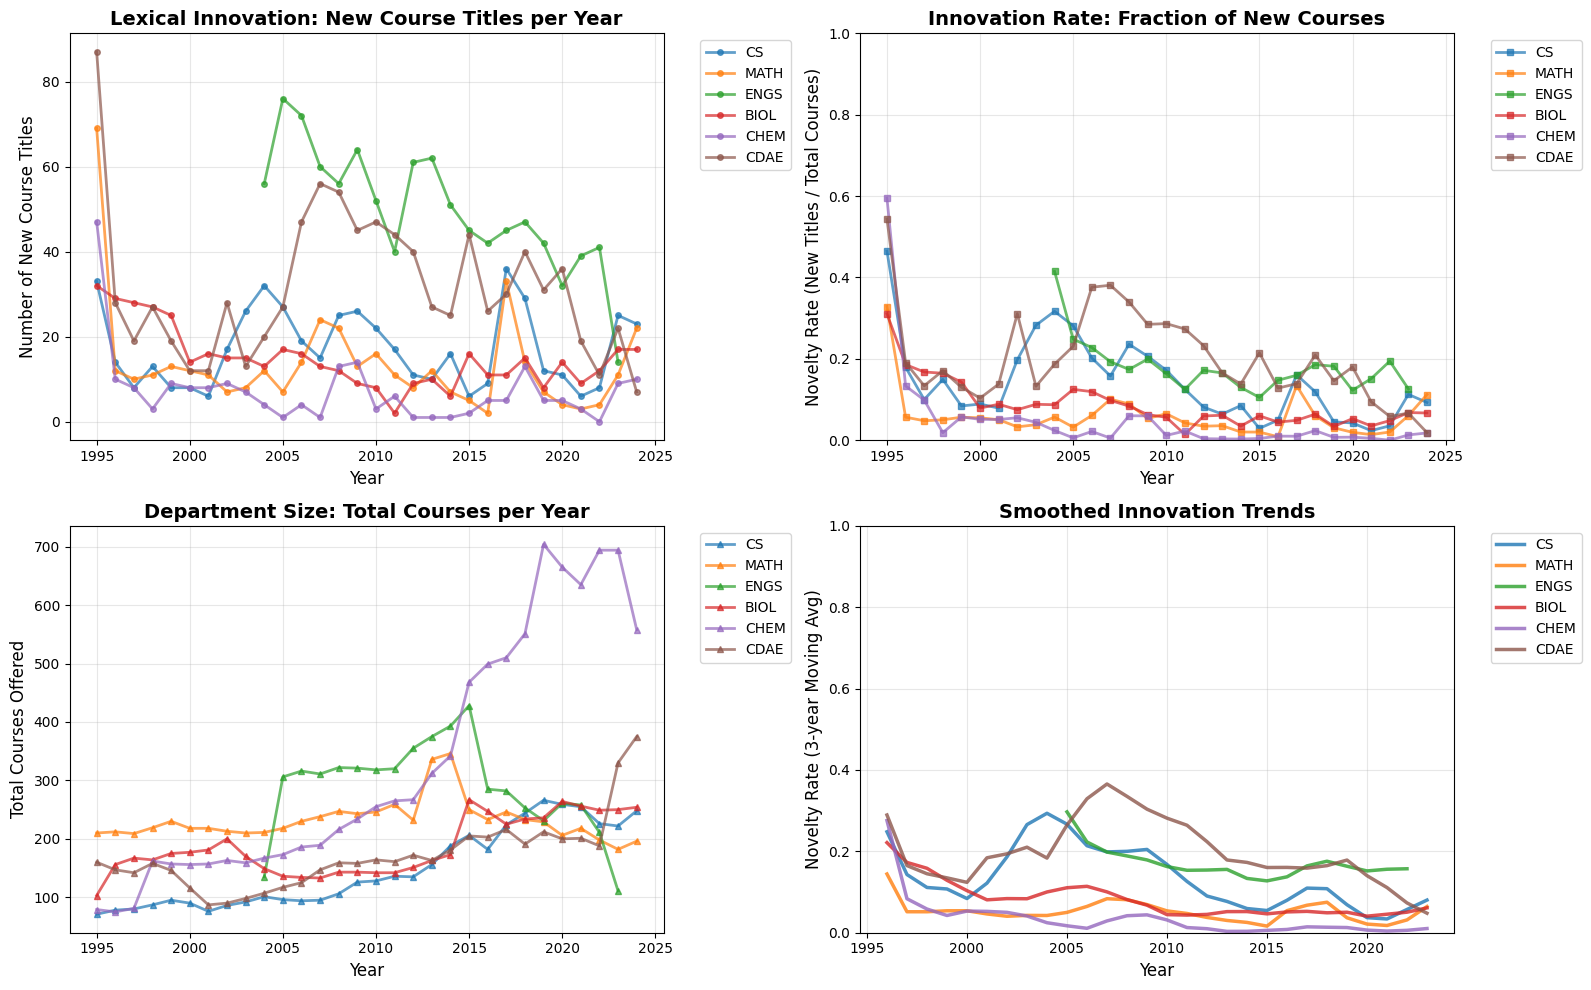


INNOVATION RATE SUMMARY STATISTICS

CS:
  Average novelty rate: 0.142
  Peak novelty rate: 0.465 (Year 1995)
  Total new titles introduced: 518

MATH:
  Average novelty rate: 0.060
  Peak novelty rate: 0.329 (Year 1995)
  Total new titles introduced: 404

ENGS:
  Average novelty rate: 0.179
  Peak novelty rate: 0.415 (Year 2004)
  Total new titles introduced: 997

BIOL:
  Average novelty rate: 0.088
  Peak novelty rate: 0.311 (Year 1995)
  Total new titles introduced: 446

CHEM:
  Average novelty rate: 0.047
  Peak novelty rate: 0.595 (Year 1995)
  Total new titles introduced: 215

CDAE:
  Average novelty rate: 0.200
  Peak novelty rate: 0.544 (Year 1995)
  Total new titles introduced: 943


In [37]:
# Visualize Lexical Novelty over Time
selected_depts = ['CS', 'MATH', 'ENGS', 'BIOL', 'CHEM', 'CDAE']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: New Title Count over time
ax1 = axes[0, 0]
for dept in selected_depts:
    dept_data = novelty_df[novelty_df['Department'] == dept]
    if len(dept_data) > 0:
        ax1.plot(dept_data['Year'], dept_data['New_Title_Count'],
                marker='o', linewidth=2, markersize=4, label=dept, alpha=0.7)

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of New Course Titles', fontsize=12)
ax1.set_title('Lexical Innovation: New Course Titles per Year', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Novelty Rate over time
ax2 = axes[0, 1]
for dept in selected_depts:
    dept_data = novelty_df[novelty_df['Department'] == dept]
    if len(dept_data) > 0:
        ax2.plot(dept_data['Year'], dept_data['Novelty_Rate'],
                marker='s', linewidth=2, markersize=4, label=dept, alpha=0.7)

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Novelty Rate (New Titles / Total Courses)', fontsize=12)
ax2.set_title('Innovation Rate: Fraction of New Courses', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

# Plot 3: Total courses over time
ax3 = axes[1, 0]
for dept in selected_depts:
    dept_data = novelty_df[novelty_df['Department'] == dept]
    if len(dept_data) > 0:
        ax3.plot(dept_data['Year'], dept_data['Total_Courses'],
                marker='^', linewidth=2, markersize=4, label=dept, alpha=0.7)

ax3.set_xlabel('Year', fontsize=12)
ax3.set_ylabel('Total Courses Offered', fontsize=12)
ax3.set_title('Department Size: Total Courses per Year', fontsize=14, fontweight='bold')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: Moving average of novelty rate (smoothed)
ax4 = axes[1, 1]
window = 3  # 3-year moving average
for dept in selected_depts:
    dept_data = novelty_df[novelty_df['Department'] == dept].copy()
    if len(dept_data) > 0:
        dept_data = dept_data.sort_values('Year')
        dept_data['Novelty_MA'] = dept_data['Novelty_Rate'].rolling(window=window, center=True).mean()
        ax4.plot(dept_data['Year'], dept_data['Novelty_MA'],
                linewidth=2.5, label=dept, alpha=0.8)

ax4.set_xlabel('Year', fontsize=12)
ax4.set_ylabel(f'Novelty Rate ({window}-year Moving Avg)', fontsize=12)
ax4.set_title('Smoothed Innovation Trends', fontsize=14, fontweight='bold')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('department_innovation_rate.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("INNOVATION RATE SUMMARY STATISTICS")
print("="*70)
for dept in selected_depts:
    dept_data = novelty_df[novelty_df['Department'] == dept]
    if len(dept_data) > 0:
        avg_novelty = dept_data['Novelty_Rate'].mean()
        max_novelty = dept_data['Novelty_Rate'].max()
        max_year = dept_data.loc[dept_data['Novelty_Rate'].idxmax(), 'Year']
        total_new = dept_data['New_Title_Count'].sum()

        print(f"\n{dept}:")
        print(f"  Average novelty rate: {avg_novelty:.3f}")
        print(f"  Peak novelty rate: {max_novelty:.3f} (Year {max_year})")
        print(f"  Total new titles introduced: {total_new}")

In [38]:
df['Title'].unique()

array(['ABIO Graduate Seminar', 'One Health: Zoonoses',
       "Master's Thesis Research", ..., 'Acting V:Shakespeare Scn Study',
       'Ecological Ordination', 'Gender & Law'],
      shape=(26342,), dtype=object)

In [39]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(df['Title'].tolist(), show_progress_bar=True)

# Cluster within each subject
clustered = []
for dept, group in df.groupby('Subject'):
    dept_embeddings = model.encode(group['Title'].tolist())
    # DBSCAN groups items with high cosine similarity (1 - eps)
    clustering = DBSCAN(eps=0.25, min_samples=1, metric='cosine').fit(dept_embeddings)
    group['Cluster'] = [f"{dept}_{label}" for label in clustering.labels_]
    clustered.append(group)

result = pd.concat(clustered)
print(result)

Batches:   0%|          | 0/7956 [00:00<?, ?it/s]

       Subject     #                     Title Comp Numb  Sec Ptrm Lec Lab  \
7259      ABIO  6020     ABIO Graduate Seminar     14772    A    1     SEM   
7260      ABIO  6090      One Health: Zoonoses     15792  OL1    1     ONL   
7261      ABIO  6391  Master's Thesis Research     14766    A    1      TD   
7262      ABIO  6391  Master's Thesis Research     14767    B    1      TD   
7263      ABIO  6391  Master's Thesis Research     14768    C    1      TD   
...        ...   ...                       ...       ...  ...  ...     ...   
258739    ZOOL   373           Grad Colloquium     15483    E  NaN       L   
258740    ZOOL   381            Special Topics     12962    A  NaN       L   
258741    ZOOL   381            Special Topics     17024    B  NaN       L   
258742    ZOOL   391        Master Thesis Rsch     12963    A  NaN       T   
258743    ZOOL   491        Doctoral Diss Rsch     12964    A  NaN       T   

       Attr Camp Code Coll Code  ...            Instructor    N

In [40]:
# Display all unique subjects/departments
unique_subjects = sorted(result['Subject'].unique())
print(f"Total number of departments: {len(unique_subjects)}\n")
print("Departments:")
for i, subject in enumerate(unique_subjects, 1):
    n_courses = len(result[result['Subject'] == subject])
    print(f"{i:3d}. {subject:8s} - {n_courses:4d} courses")


Total number of departments: 217

Departments:
  1. ABIO     -  162 courses
  2. AGBI     -  344 courses
  3. AGRI     -  494 courses
  4. AH       -  235 courses
  5. AIS      -  193 courses
  6. ALAN     -  173 courses
  7. ALE      -   83 courses
  8. ANFS     -  446 courses
  9. ANNB     -  462 courses
 10. ANPS     -  590 courses
 11. ANTH     - 2248 courses
 12. ARBC     -  125 courses
 13. ART      - 1850 courses
 14. ARTH     -  580 courses
 15. ARTS     - 2178 courses
 16. AS       -  474 courses
 17. ASCI     - 2945 courses
 18. ASL      -  843 courses
 19. ASTR     -  374 courses
 20. ASTU     -    4 courses
 21. AT       -  316 courses
 22. BCOR     - 2761 courses
 23. BHSC     -  194 courses
 24. BIOC     - 1578 courses
 25. BIOE     -  240 courses
 26. BIOL     - 5584 courses
 27. BIOS     -    2 courses
 28. BME      -  500 courses
 29. BMED     -   83 courses
 30. BMT      -  298 courses
 31. BOT      -  655 courses
 32. BSAD     - 5911 courses
 33. BSCI     -   80 cour

In [41]:
result['Cluster'].unique()

array(['ABIO_0', 'ABIO_1', 'ABIO_2', ..., 'ZOOL_15', 'ZOOL_16', 'ZOOL_17'],
      shape=(17413,), dtype=object)

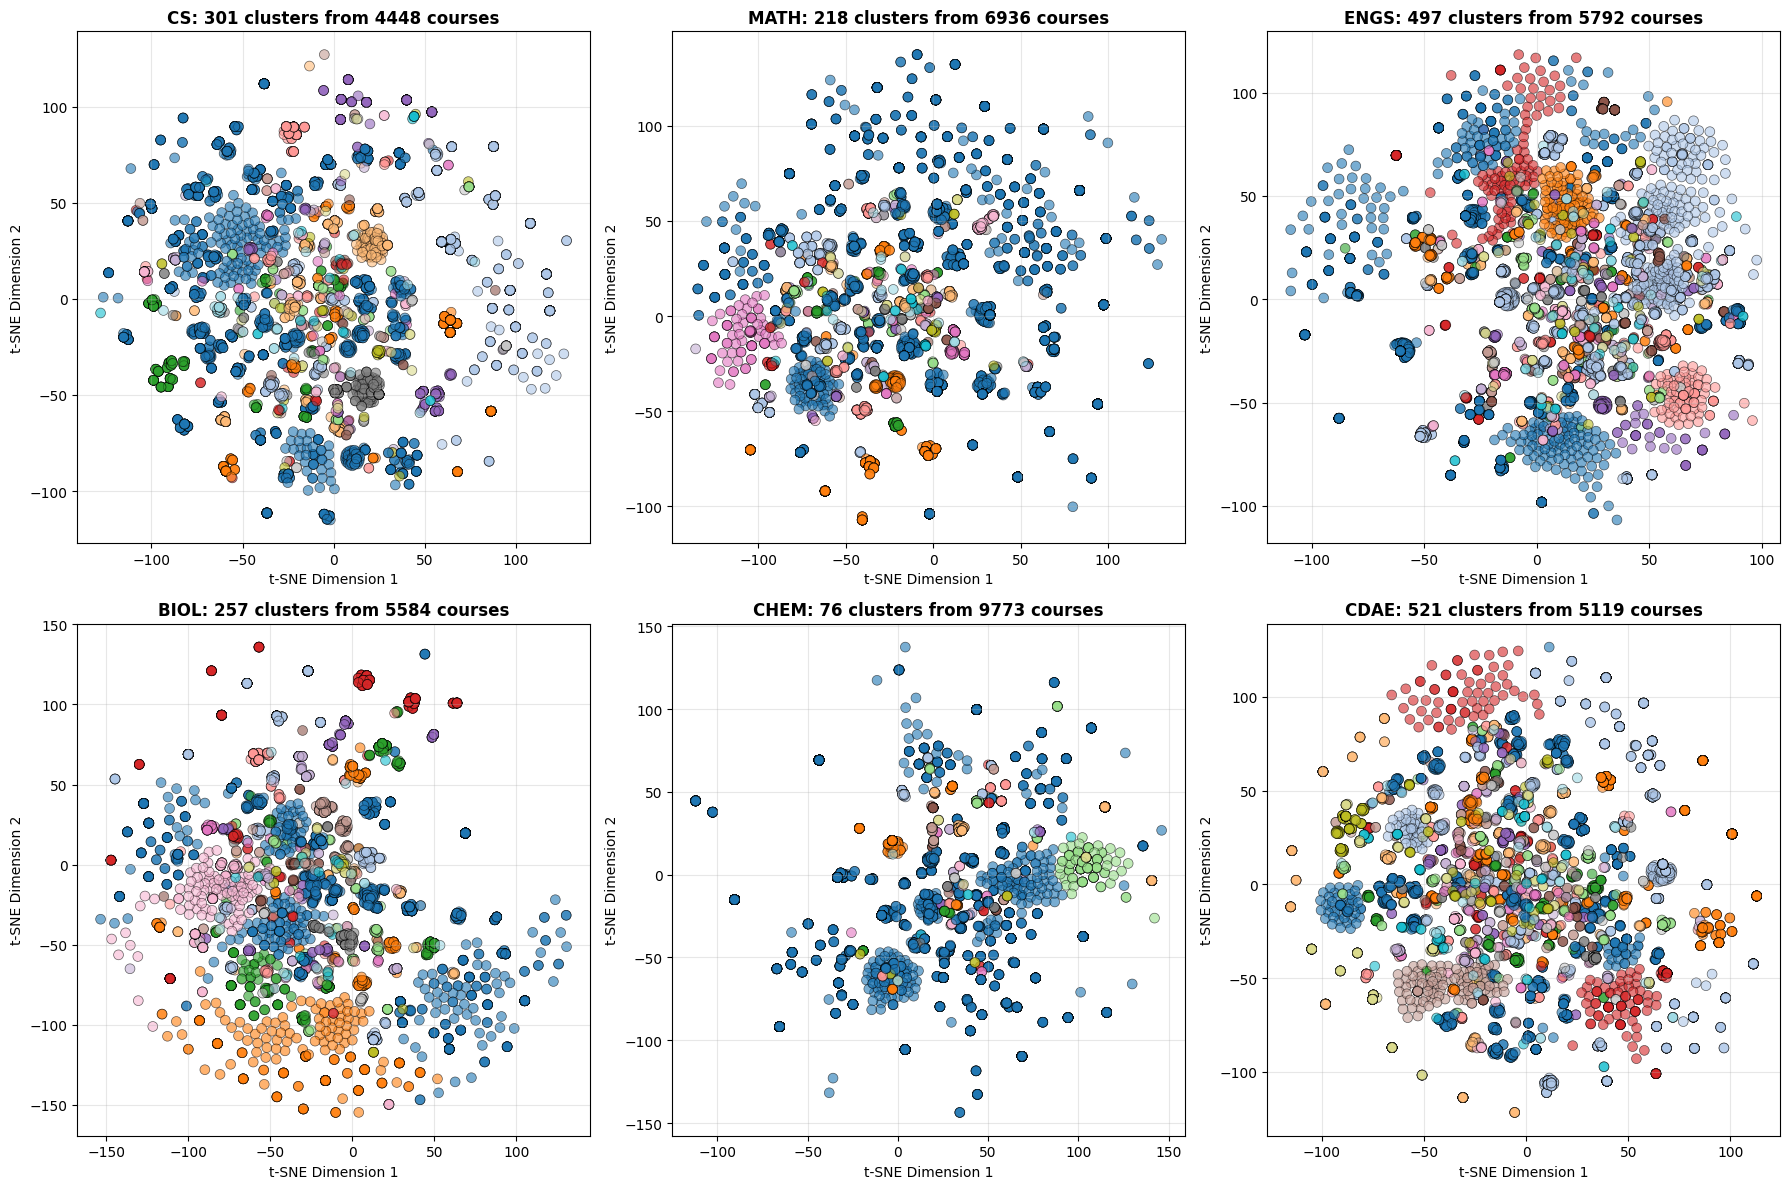

In [42]:
# Visualize clusters using dimensionality reduction
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Pick a few interesting departments to visualize
departments_to_plot = ['CS', 'MATH', 'ENGS', 'BIOL', 'CHEM', 'CDAE']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, dept in enumerate(departments_to_plot):
    if dept not in result['Subject'].values:
        axes[idx].text(0.5, 0.5, f'{dept} not found', ha='center', va='center')
        axes[idx].set_title(f'{dept}')
        continue

    # Get data for this department
    dept_data = result[result['Subject'] == dept].copy()
    dept_embeddings = model.encode(dept_data['Title'].tolist())

    # Reduce to 2D using t-SNE
    if len(dept_embeddings) > 1:
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(dept_embeddings)-1))
        embeddings_2d = tsne.fit_transform(dept_embeddings)

        # Get cluster labels
        cluster_labels = dept_data['Cluster'].str.replace(f'{dept}_', '').astype(int).values
        n_clusters = len(set(cluster_labels))

        # Create scatter plot
        scatter = axes[idx].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                                   c=cluster_labels, cmap='tab20',
                                   alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

        axes[idx].set_title(f'{dept}: {n_clusters} clusters from {len(dept_data)} courses',
                           fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('t-SNE Dimension 1')
        axes[idx].set_ylabel('t-SNE Dimension 2')
        axes[idx].grid(True, alpha=0.3)
    else:
        axes[idx].text(0.5, 0.5, f'{dept}: Too few courses', ha='center', va='center')
        axes[idx].set_title(f'{dept}')

plt.tight_layout()
plt.savefig('clustering_tsne_by_department.png', dpi=300, bbox_inches='tight')
plt.show()

CCDF Analysis by Department
CS      : 301 clusters, β=0.775
MATH    : 218 clusters, β=0.722
ENGS    : 497 clusters, β=0.866
BIOL    : 257 clusters, β=0.753
CHEM    :  76 clusters, β=0.523
CDAE    : 521 clusters, β=0.984


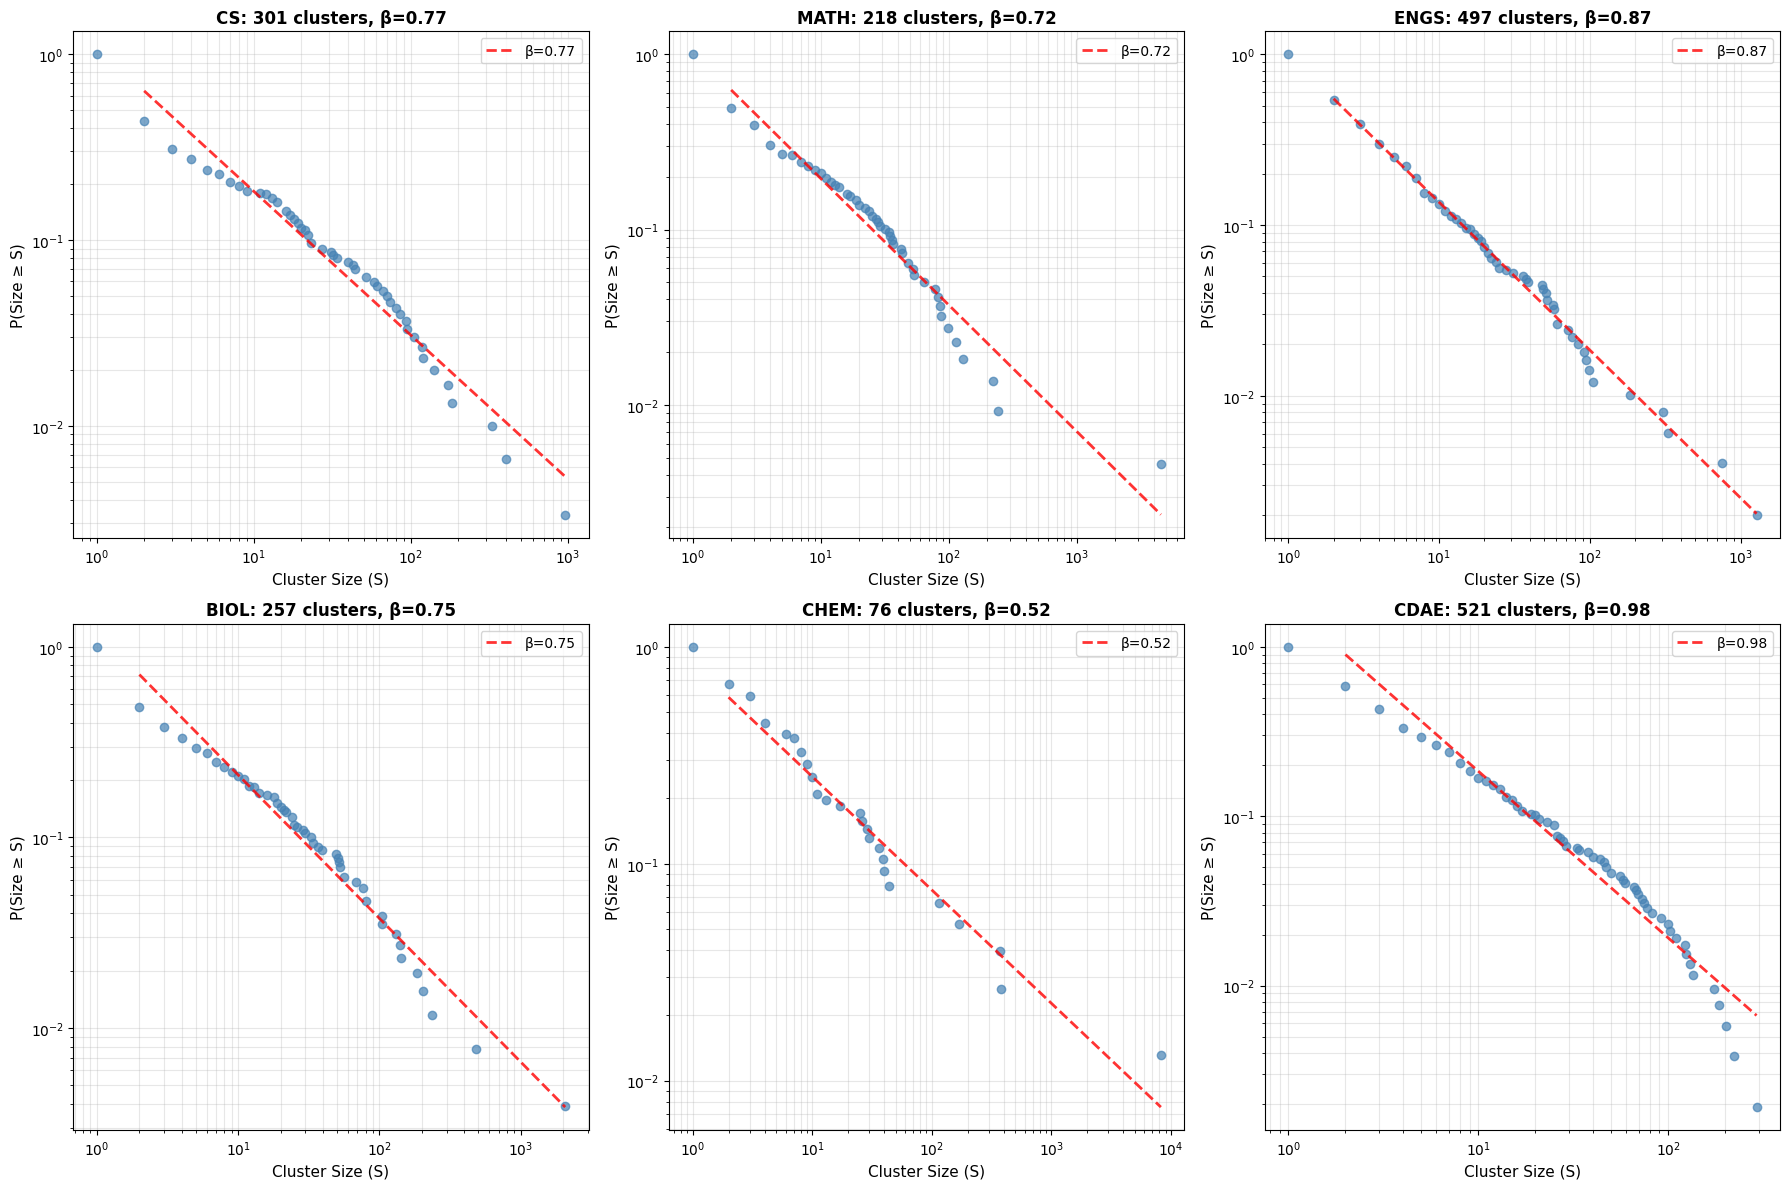


Note: β (beta) represents the power-law exponent of the CCDF
      Higher β = steeper decline (more uniform cluster sizes)
      Lower β = gentler decline (more heavy-tailed distribution)


In [43]:
# CCDF Analysis for Each Department
departments_to_plot = ['CS', 'MATH', 'ENGS', 'BIOL', 'CHEM', 'CDAE']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

print("CCDF Analysis by Department")
print("="*70)

for idx, dept in enumerate(departments_to_plot):
    if dept not in result['Subject'].values:
        axes[idx].text(0.5, 0.5, f'{dept} not found', ha='center', va='center')
        axes[idx].set_title(f'{dept}')
        continue

    # Get cluster sizes for this department
    dept_data = result[result['Subject'] == dept]
    dept_clusters = dept_data.groupby('Cluster').size().sort_values(ascending=False)

    if len(dept_clusters) < 2:
        axes[idx].text(0.5, 0.5, f'{dept}: Too few clusters', ha='center', va='center')
        axes[idx].set_title(f'{dept}')
        continue

    sizes = dept_clusters.values

    # Calculate CCDF
    unique_sizes = np.unique(sizes)
    ccdf = np.array([np.sum(sizes >= s) for s in unique_sizes]) / len(sizes)

    # Plot CCDF
    axes[idx].loglog(unique_sizes, ccdf, 'o', markersize=6, alpha=0.7, color='steelblue')
    axes[idx].set_xlabel('Cluster Size (S)', fontsize=11)
    axes[idx].set_ylabel('P(Size ≥ S)', fontsize=11)
    axes[idx].grid(True, alpha=0.3, which='both')

    # Fit power law to CCDF
    min_size_for_fit = 2
    mask = unique_sizes >= min_size_for_fit

    if np.sum(mask) > 2:
        log_unique_sizes = np.log(unique_sizes[mask])
        log_ccdf = np.log(ccdf[mask])

        try:
            coeffs_ccdf = np.polyfit(log_unique_sizes, log_ccdf, 1)
            beta = -coeffs_ccdf[0]

            fit_ccdf = np.exp(coeffs_ccdf[1]) * unique_sizes[mask]**coeffs_ccdf[0]
            axes[idx].loglog(unique_sizes[mask], fit_ccdf, 'r--', linewidth=2, alpha=0.8,
                           label=f'β={beta:.2f}')

            axes[idx].set_title(f'{dept}: {len(dept_clusters)} clusters, β={beta:.2f}',
                              fontsize=12, fontweight='bold')
            axes[idx].legend(fontsize=10)

            print(f"{dept:8s}: {len(dept_clusters):3d} clusters, β={beta:.3f}")
        except:
            axes[idx].set_title(f'{dept}: {len(dept_clusters)} clusters',
                              fontsize=12, fontweight='bold')
            print(f"{dept:8s}: {len(dept_clusters):3d} clusters, fit failed")
    else:
        axes[idx].set_title(f'{dept}: {len(dept_clusters)} clusters',
                          fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('department_ccdf_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("Note: β (beta) represents the power-law exponent of the CCDF")
print("      Higher β = steeper decline (more uniform cluster sizes)")
print("      Lower β = gentler decline (more heavy-tailed distribution)")

Computing t-SNE for 5000 courses...


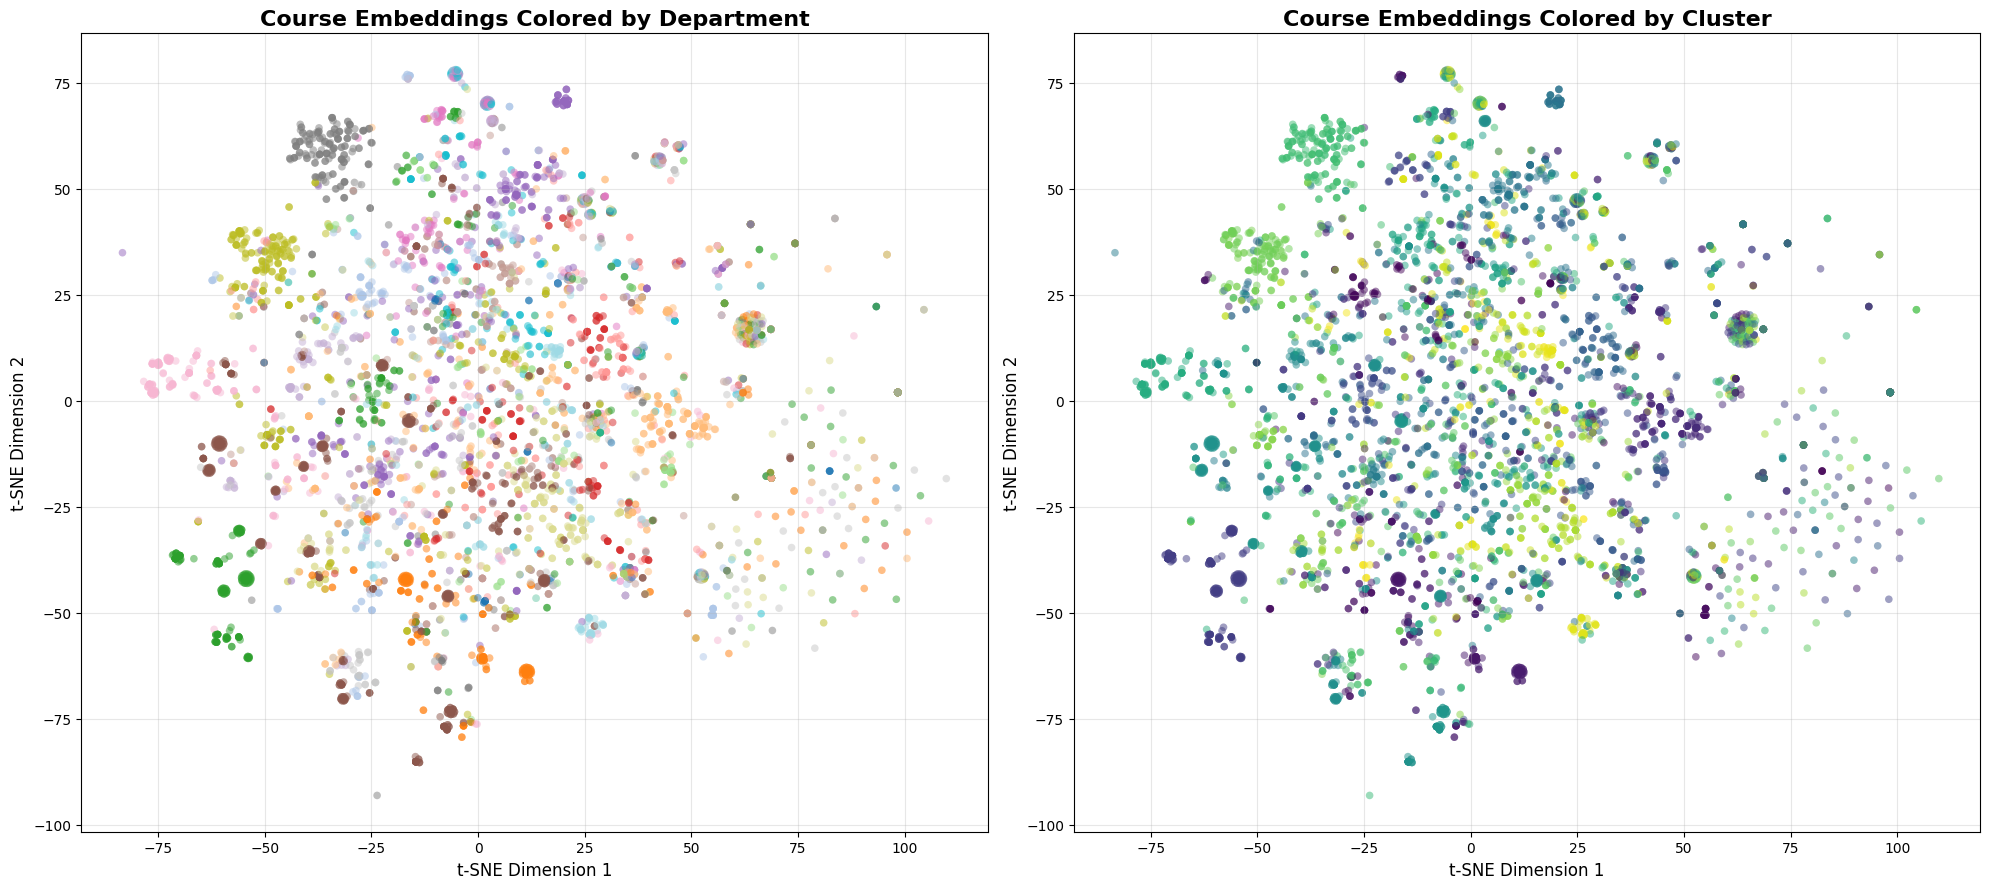


Total unique clusters: 17413
Total courses: 254588


In [44]:
# Create a large overview of all courses across all departments
# Sample if there are too many courses
sample_size = min(5000, len(result))
sample_df = result.sample(n=sample_size, random_state=42) if len(result) > sample_size else result

# Get embeddings for sampled data
sample_embeddings = model.encode(sample_df['Title'].tolist())

# Reduce to 2D
print(f"Computing t-SNE for {len(sample_df)} courses...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(sample_embeddings)-1))
embeddings_2d = tsne.fit_transform(sample_embeddings)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# Plot 1: Color by department
dept_codes = sample_df['Subject'].astype('category').cat.codes.values
scatter1 = ax1.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                       c=dept_codes, cmap='tab20',
                       alpha=0.5, s=30, edgecolors='none')
ax1.set_title('Course Embeddings Colored by Department', fontsize=16, fontweight='bold')
ax1.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax1.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Color by cluster
cluster_codes = sample_df['Cluster'].astype('category').cat.codes.values
scatter2 = ax2.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                       c=cluster_codes, cmap='viridis',
                       alpha=0.5, s=30, edgecolors='none')
ax2.set_title('Course Embeddings Colored by Cluster', fontsize=16, fontweight='bold')
ax2.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax2.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTotal unique clusters: {result['Cluster'].nunique()}")
print(f"Total courses: {len(result)}")

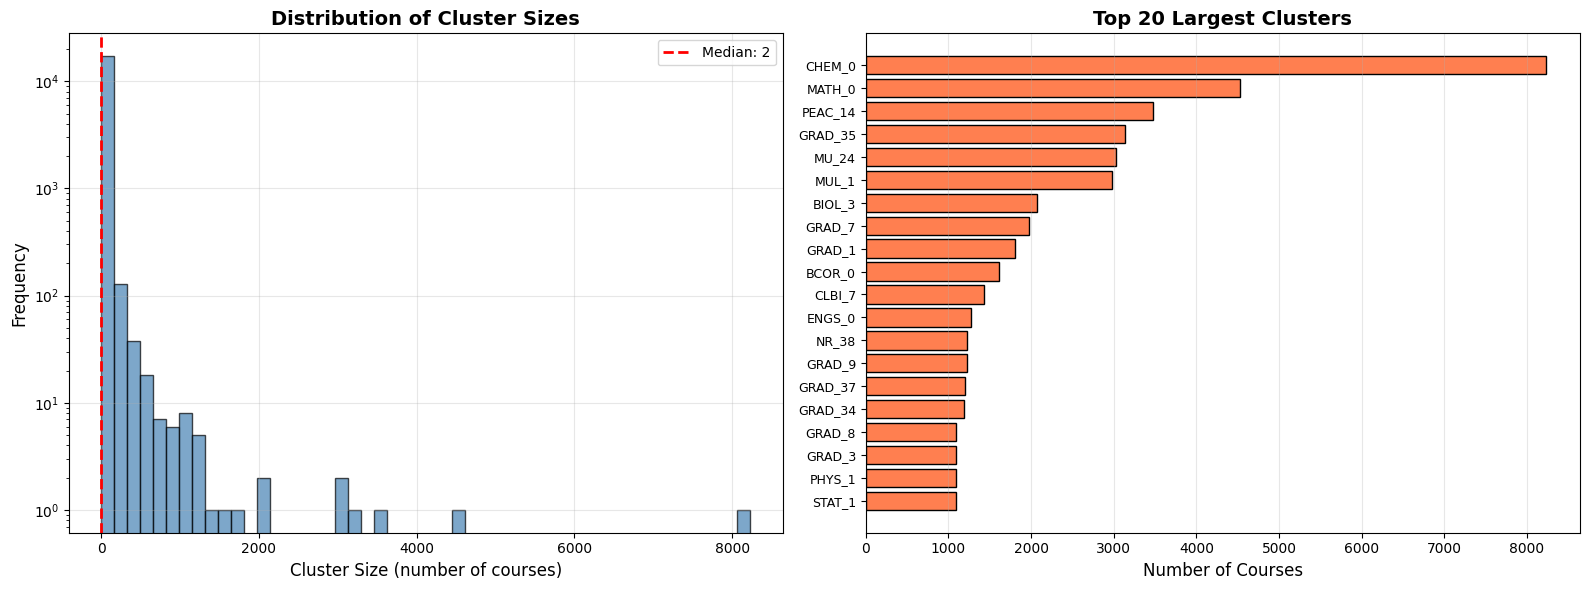


Cluster Statistics:
Total clusters: 17413
Mean cluster size: 14.62
Median cluster size: 2
Largest cluster: 8230 courses
Smallest cluster: 1 courses
Singleton clusters (size 1): 7826


In [45]:
# Analyze cluster sizes and create a density visualization
cluster_sizes = result.groupby('Cluster').size().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Cluster size distribution
ax1.hist(cluster_sizes.values, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Cluster Size (number of courses)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Cluster Sizes', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
ax1.axvline(cluster_sizes.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {cluster_sizes.median():.0f}')
ax1.legend()

# Plot 2: Top clusters by size
top_n = 20
top_clusters = cluster_sizes.head(top_n)
ax2.barh(range(len(top_clusters)), top_clusters.values, color='coral', edgecolor='black')
ax2.set_yticks(range(len(top_clusters)))
ax2.set_yticklabels(top_clusters.index, fontsize=9)
ax2.set_xlabel('Number of Courses', fontsize=12)
ax2.set_title(f'Top {top_n} Largest Clusters', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('cluster_size_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCluster Statistics:")
print(f"Total clusters: {len(cluster_sizes)}")
print(f"Mean cluster size: {cluster_sizes.mean():.2f}")
print(f"Median cluster size: {cluster_sizes.median():.0f}")
print(f"Largest cluster: {cluster_sizes.max()} courses")
print(f"Smallest cluster: {cluster_sizes.min()} courses")
print(f"Singleton clusters (size 1): {(cluster_sizes == 1).sum()}")

Zipf's Law Analysis for Cluster Sizes
Total clusters: 17413
Largest cluster: 8230 courses
Smallest cluster: 1 courses

Top 10 clusters:
  Rank 1: CHEM_0               - 8230 courses
  Rank 2: MATH_0               - 4527 courses
  Rank 3: PEAC_14              - 3478 courses
  Rank 4: GRAD_35              - 3134 courses
  Rank 5: MU_24                - 3022 courses
  Rank 6: MUL_1                - 2979 courses
  Rank 7: BIOL_3               - 2070 courses
  Rank 8: GRAD_7               - 1977 courses
  Rank 9: GRAD_1               - 1803 courses
  Rank 10: BCOR_0               - 1613 courses


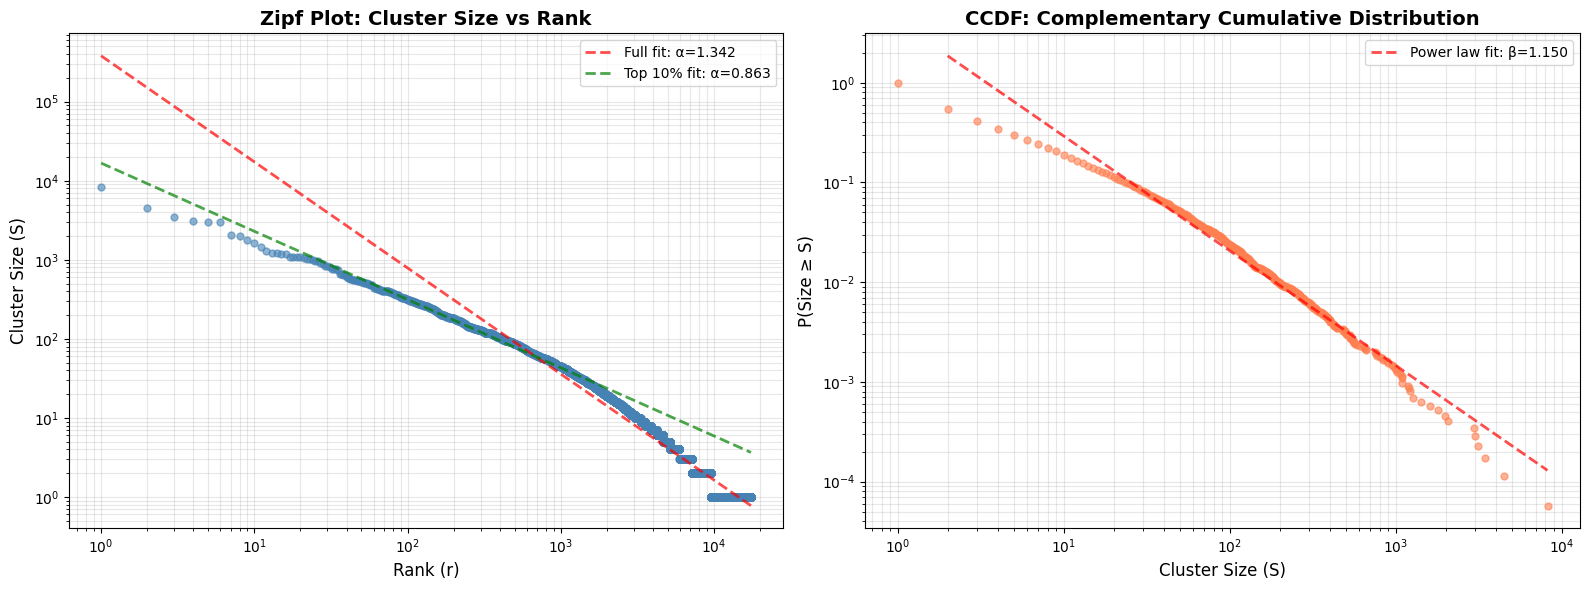


Zipf's Law Fit Results:
  Full data exponent (α): 1.342
  Top 20% exponent (α): 0.863
  CCDF exponent (β): 1.150

Note: Classic Zipf's law has α = 1.0
      α < 1: More equal distribution
      α > 1: More concentrated (winner-takes-all)


In [46]:
# Zipf Distribution Analysis for Cluster Sizes
# Similar to HW4 - analyze cluster size rankings

# Get cluster sizes and rank them
cluster_sizes = result.groupby('Cluster').size().sort_values(ascending=False)
ranks = np.arange(1, len(cluster_sizes) + 1)
sizes = cluster_sizes.values

print(f"Zipf's Law Analysis for Cluster Sizes")
print(f"="*60)
print(f"Total clusters: {len(cluster_sizes)}")
print(f"Largest cluster: {sizes[0]} courses")
print(f"Smallest cluster: {sizes[-1]} courses")
print(f"\nTop 10 clusters:")
for i in range(min(10, len(cluster_sizes))):
    print(f"  Rank {i+1}: {cluster_sizes.index[i]:20s} - {sizes[i]:4d} courses")

# Create Zipf plot (log-log of rank vs size)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Zipf plot (rank vs size on log-log scale)
axes[0].loglog(ranks, sizes, 'o', markersize=5, alpha=0.6, color='steelblue')
axes[0].set_xlabel('Rank (r)', fontsize=12)
axes[0].set_ylabel('Cluster Size (S)', fontsize=12)
axes[0].set_title('Zipf Plot: Cluster Size vs Rank', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, which='both')

# Fit power law to the data: S(r) = C * r^(-α)
# Taking log: log(S) = log(C) - α * log(r)
log_ranks = np.log(ranks)
log_sizes = np.log(sizes)

# Fit different portions of the curve
# Full fit
coeffs_full = np.polyfit(log_ranks, log_sizes, 1)
alpha_full = -coeffs_full[0]
C_full = np.exp(coeffs_full[1])

# Fit to top 10% of data (more reliable for Zipf)
top_10_percent = max(10, int(len(ranks) * 0.10))
coeffs_top = np.polyfit(log_ranks[:top_10_percent], log_sizes[:top_10_percent], 1)
alpha_top = -coeffs_top[0]
C_top = np.exp(coeffs_top[1])

# Plot fitted lines
fit_full = C_full * ranks**(-alpha_full)
fit_top = C_top * ranks**(-alpha_top)

axes[0].loglog(ranks, fit_full, 'r--', linewidth=2, alpha=0.7,
              label=f'Full fit: α={alpha_full:.3f}')
axes[0].loglog(ranks, fit_top, 'g--', linewidth=2, alpha=0.7,
              label=f'Top 10% fit: α={alpha_top:.3f}')
axes[0].legend(fontsize=10)

# Plot 2: CCDF (Complementary Cumulative Distribution Function)
# P(S ≥ s) - probability that cluster size is at least s
unique_sizes = np.unique(sizes)
ccdf = np.array([np.sum(sizes >= s) for s in unique_sizes]) / len(sizes)

axes[1].loglog(unique_sizes, ccdf, 'o', markersize=5, alpha=0.6, color='coral')
axes[1].set_xlabel('Cluster Size (S)', fontsize=12)
axes[1].set_ylabel('P(Size ≥ S)', fontsize=12)
axes[1].set_title('CCDF: Complementary Cumulative Distribution', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, which='both')

# Fit power law to CCDF: P(S ≥ s) ~ s^(-β)
# Filter out very small sizes for better fit
min_size_for_fit = 2
mask = unique_sizes >= min_size_for_fit
if np.sum(mask) > 2:
    log_unique_sizes = np.log(unique_sizes[mask])
    log_ccdf = np.log(ccdf[mask])

    coeffs_ccdf = np.polyfit(log_unique_sizes, log_ccdf, 1)
    beta = -coeffs_ccdf[0]

    fit_ccdf = np.exp(coeffs_ccdf[1]) * unique_sizes[mask]**coeffs_ccdf[0]
    axes[1].loglog(unique_sizes[mask], fit_ccdf, 'r--', linewidth=2, alpha=0.7,
                  label=f'Power law fit: β={beta:.3f}')
    axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('cluster_zipf_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print(f"Zipf's Law Fit Results:")
print(f"  Full data exponent (α): {alpha_full:.3f}")
print(f"  Top 20% exponent (α): {alpha_top:.3f}")
if 'beta' in locals():
    print(f"  CCDF exponent (β): {beta:.3f}")
print(f"\nNote: Classic Zipf's law has α = 1.0")
print(f"      α < 1: More equal distribution")
print(f"      α > 1: More concentrated (winner-takes-all)")
